In [ ]:
import pandas as pd
import dask.dataframe as dd
import tracemalloc
import time
import os
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded!")

All libraries loaded!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/HPDP_A2/review-California_10.json'

# Verify it exists and check size
file_size_mb = os.path.getsize(FILE_PATH) / (1024 * 1024)
print(f"File found!")
print(f"File size: {file_size_mb:.2f} MB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
File found!
File size: 11929.34 MB


In [ ]:
# Load just 10,000 rows to inspect the structure
df_sample = pd.read_json(FILE_PATH, lines=True, nrows=10000)

print("=== COLUMN NAMES & DATA TYPES ===")
print(df_sample.dtypes)
print(f"\nShape: {df_sample.shape}")
print("\n=== PREVIEW ===")
df_sample.head()

=== COLUMN NAMES & DATA TYPES ===
user_id    float64
name        object
time         int64
rating       int64
text        object
pics        object
resp        object
gmap_id     object
dtype: object

Shape: (10000, 8)

=== PREVIEW ===


,user_id,name,time,rating,text,pics,resp,gmap_id
0,1.089912e+20,Song Ro,1609909927056,5,Love there korean rice cake.,None,None,0x80c2c778e3b73d33:0xbdc58662a4a97d49
1,1.112903e+20,Rafa Robles,1612849648663,5,Good very good,None,None,0x80c2c778e3b73d33:0xbdc58662a4a97d49
2,1.126404e+20,David Han,1583643882296,4,They make Korean traditional food very properly.,None,None,0x80c2c778e3b73d33:0xbdc58662a4a97d49
3,1.174403e+20,Anthony Kim,1551938216355,5,Short ribs are very delicious.,None,None,0x80c2c778e3b73d33:0xbdc58662a4a97d49
4,1.005808e+20,Mario Marzouk,1494910901933,5,Great food and prices the portions are large,None,None,0x80c2c778e3b73d33:0xbdc58662a4a97d49


## Pandas Baseline: Initial Data Loading

We establish a baseline by loading 2,000,000 rows from the dataset using default Pandas settings.
The full 12GB file caused a MemoryError when loaded without any optimisation strategy,
demonstrating the limitations of Pandas with large datasets.
We record load time and peak memory as a reference point for all subsequent strategies.

In [ ]:
COLS_TO_USE = ['user_id', 'name', 'time', 'rating', 'text', 'gmap_id']

tracemalloc.start()
start_time = time.time()

df = pd.read_json(FILE_PATH, lines=True, nrows=2000000)
df = df[COLS_TO_USE]

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

baseline_time = round(end_time - start_time, 2)
baseline_memory = round(peak_mem / (1024 * 1024), 2)

print("=== PANDAS BASELINE METRICS ===")
print(f"Load time   : {baseline_time} seconds")
print(f"Peak memory : {baseline_memory} MB")
print(f"Shape       : {df.shape[0]:,} rows × {df.shape[1]} columns")

=== PANDAS BASELINE METRICS ===
Load time   : 117.95 seconds
Peak memory : 5704.08 MB
Shape       : 2,000,000 rows × 6 columns


In [ ]:
print("=== DATA TYPES ===")
print(df.dtypes)
print("\n=== MISSING VALUES ===")
print(df.isnull().sum())
print("\n=== PREVIEW ===")
df.head()

=== DATA TYPES ===
user_id    float64
name        object
time         int64
rating       int64
text        object
gmap_id     object
dtype: object

=== MISSING VALUES ===
user_id         0
name            0
time            0
rating          0
text       849964
gmap_id         0
dtype: int64

=== PREVIEW ===


,user_id,name,time,rating,text,gmap_id
0,1.089912e+20,Song Ro,1609909927056,5,Love there korean rice cake.,0x80c2c778e3b73d33:0xbdc58662a4a97d49
1,1.112903e+20,Rafa Robles,1612849648663,5,Good very good,0x80c2c778e3b73d33:0xbdc58662a4a97d49
2,1.126404e+20,David Han,1583643882296,4,They make Korean traditional food very properly.,0x80c2c778e3b73d33:0xbdc58662a4a97d49
3,1.174403e+20,Anthony Kim,1551938216355,5,Short ribs are very delicious.,0x80c2c778e3b73d33:0xbdc58662a4a97d49
4,1.005808e+20,Mario Marzouk,1494910901933,5,Great food and prices the portions are large,0x80c2c778e3b73d33:0xbdc58662a4a97d49


## Strategy 1: Load Less Data

We reduce the number of columns loaded from 6 to 4 by dropping columns not needed for analysis
(user_id and name). Using only relevant columns means less data is allocated in memory.
This is the simplest optimisation — selecting only what you need at load time.

In [ ]:
COLS_MINIMAL = ['rating', 'text', 'gmap_id', 'time']

tracemalloc.start()
start_time = time.time()

df_s1 = pd.read_json(FILE_PATH, lines=True, nrows=2000000)
df_s1 = df_s1[COLS_MINIMAL]

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

s1_time = round(end_time - start_time, 2)
s1_memory = round(peak_mem / (1024 * 1024), 2)

print("=== STRATEGY 1: LOAD LESS DATA ===")
print(f"Load time        : {s1_time} seconds")
print(f"Peak memory      : {s1_memory} MB")
print(f"Memory saved     : {round(baseline_memory - s1_memory, 2)} MB")
print(f"Memory reduction : {round((baseline_memory - s1_memory) / baseline_memory * 100, 1)}%")
print(f"Shape            : {df_s1.shape[0]:,} rows × {df_s1.shape[1]} columns")

=== STRATEGY 1: LOAD LESS DATA ===
Load time        : 92.11 seconds
Peak memory      : 5639.82 MB
Memory saved     : 64.26 MB
Memory reduction : 1.1%
Shape            : 2,000,000 rows × 4 columns


## Strategy 2: Chunking

Instead of loading the entire dataset at once, we read the file in chunks of 100,000 rows.
Only one chunk lives in memory at a time, drastically reducing peak memory usage.
We apply a filter (rating >= 4) on each chunk, keeping only high-rated reviews.
This approach makes it possible to process files larger than available RAM.

In [ ]:
CHUNK_SIZE = 100_000
filtered_chunks = []

tracemalloc.start()
start_time = time.time()

rows_read = 0
for chunk in pd.read_json(FILE_PATH, lines=True, chunksize=CHUNK_SIZE):
    chunk = chunk[COLS_MINIMAL]
    high_rated = chunk[chunk['rating'] >= 4]
    filtered_chunks.append(high_rated)
    rows_read += len(chunk)
    if rows_read >= 2_000_000:
        break

df_s2 = pd.concat(filtered_chunks, ignore_index=True)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

s2_time = round(end_time - start_time, 2)
s2_memory = round(peak_mem / (1024 * 1024), 2)

print("=== STRATEGY 2: CHUNKING ===")
print(f"Chunk size       : {CHUNK_SIZE:,} rows per chunk")
print(f"Load time        : {s2_time} seconds")
print(f"Peak memory      : {s2_memory} MB")
print(f"Memory saved     : {round(baseline_memory - s2_memory, 2)} MB")
print(f"Memory reduction : {round((baseline_memory - s2_memory) / baseline_memory * 100, 1)}%")
print(f"Filtered rows    : {df_s2.shape[0]:,} high-rated reviews kept")

=== STRATEGY 2: CHUNKING ===
Chunk size       : 100,000 rows per chunk
Load time        : 127.12 seconds
Peak memory      : 620.65 MB
Memory saved     : 5083.43 MB
Memory reduction : 89.1%
Filtered rows    : 1,648,135 high-rated reviews kept


## Strategy 3: Data Type Optimisation

Pandas assigns default data types that are often wasteful. For example:
- rating stores values 1–5 but uses int64 (8 bytes). Downcasting to int8 (1 byte) saves 87.5% per value.
- gmap_id is a string column with many repeated values. Converting to category type stores each unique value once.
- time uses int64 but can be reduced to int32.

This strategy shrinks the memory footprint of data already loaded into memory.

In [ ]:
mem_before = round(df_s1.memory_usage(deep=True).sum() / (1024 * 1024), 2)

df_s3 = df_s1.copy()
df_s3['rating'] = df_s3['rating'].astype('int8')
df_s3['gmap_id'] = df_s3['gmap_id'].astype('category')
df_s3['time'] = df_s3['time'].astype('int32')

mem_after = round(df_s3.memory_usage(deep=True).sum() / (1024 * 1024), 2)

print("=== STRATEGY 3: DATA TYPE OPTIMISATION ===")
print(f"Memory before    : {mem_before} MB")
print(f"Memory after     : {mem_after} MB")
print(f"Memory saved     : {round(mem_before - mem_after, 2)} MB")
print(f"Memory reduction : {round((mem_before - mem_after) / mem_before * 100, 1)}%")
print(f"\nData types after optimisation:")
print(df_s3.dtypes)

=== STRATEGY 3: DATA TYPE OPTIMISATION ===
Memory before    : 452.53 MB
Memory after     : 282.85 MB
Memory saved     : 169.68 MB
Memory reduction : 37.5%

Data types after optimisation:
rating         int8
text         object
gmap_id    category
time          int32
dtype: object


In [ ]:
tracemalloc.start()
start_time = time.time()

ddf = dd.read_json(FILE_PATH, blocksize=10_000_000)
ddf = ddf[COLS_MINIMAL]
df_dask = ddf.head(2000000, compute=True)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

dask_time = round(end_time - start_time, 2)
dask_memory = round(peak_mem / (1024 * 1024), 2)

print("=== DASK METRICS ===")
print(f"Load time        : {dask_time} seconds")
print(f"Peak memory      : {dask_memory} MB")
print(f"Shape            : {df_dask.shape[0]:,} rows × {df_dask.shape[1]} columns")

=== DASK METRICS ===
Load time        : 8.41 seconds
Peak memory      : 156.62 MB
Shape            : 30,042 rows × 4 columns


In [ ]:
# ── DASK: Load same data for comparison ──────────────────
# Dask reads lazily — it only processes what we ask for.
# We use the already-loaded df_s1 (from Strategy 1)
# and convert it to Dask to measure Dask's performance.

tracemalloc.start()
start_time = time.time()

ddf = dd.from_pandas(df_s1, npartitions=4)
result = ddf.compute()

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

dask_time = round(end_time - start_time, 2)
dask_memory = round(peak_mem / (1024 * 1024), 2)

print("=== DASK METRICS ===")
print(f"Load time        : {dask_time} seconds")
print(f"Peak memory      : {dask_memory} MB")
print(f"Shape            : {result.shape[0]:,} rows × {result.shape[1]} columns")

In [ ]:
# ── SUMMARY: Pandas vs Strategies vs Dask ────────────────

summary = pd.DataFrame({
    'Approach': [
        'Pandas Baseline',
        'Strategy 1: Load Less Data',
        'Strategy 2: Chunking',
        'Strategy 3: dtype Optimisation',
        'Dask'
    ],
    'Load Time (s)': [
        baseline_time,
        s1_time,
        s2_time,
        '-',
        dask_time
    ],
    'Peak Memory (MB)': [
        baseline_memory,
        s1_memory,
        s2_memory,
        mem_after,
        dask_memory
    ]
})

print("=== FULL COMPARISON TABLE ===")
print(summary.to_string(index=False))

## Summary & Observations

### Dataset
- Source: California Google Local Reviews (Google Maps)
- Full file size: ~12 GB (11,929 MB)
- Rows used for benchmarking: 2,000,000
- Columns used: rating, text, gmap_id, time

### Key Findings
- **Pandas Baseline** loaded 2M rows in 266 seconds using 4490 MB of memory. Attempting to load the full 12GB file caused a MemoryError.
- **Strategy 1 (Load Less Data)** reduced the number of columns from 6 to 4, but peak memory remained the same because Pandas still reads the full file before selecting columns.
- **Strategy 2 (Chunking)** gave the biggest improvement — memory dropped from 4490 MB to 564 MB (87% reduction) by processing 100,000 rows at a time instead of everything at once.
- **Strategy 3 (Data Type Optimisation)** further reduced in-memory size to 282 MB by downcasting rating to int8 and converting gmap_id to category type.
- **Dask** completed in only 56 seconds using 1298 MB — significantly faster and lighter than the Pandas baseline.

### Conclusion
Pandas alone cannot handle datasets exceeding available RAM. Chunking is the most effective single strategy for memory reduction. Dask outperforms Pandas significantly in both speed and memory for large-scale data processing.

In [ ]:
print(f"Pandas Baseline  → Time: {baseline_time}s  | Memory: {baseline_memory} MB")
print(f"Strategy 1       → Time: {s1_time}s  | Memory: {s1_memory} MB")
print(f"Strategy 2       → Time: {s2_time}s | Memory: {s2_memory} MB")
print(f"Strategy 3       → Memory after: {mem_after} MB")
print(f"Dask             → Time: {dask_time}s  | Memory: {dask_memory} MB")

Pandas Baseline  → Time: 117.95s  | Memory: 5704.08 MB
Strategy 1       → Time: 92.11s  | Memory: 5639.82 MB
Strategy 2       → Time: 127.12s | Memory: 620.65 MB
Strategy 3       → Memory after: 282.85 MB
Dask             → Time: 29.23s  | Memory: 827.3 MB


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FILE_PATH = '/content/drive/MyDrive/HPDP_A2/review-California_10.json'

# Verify
import os
print(os.path.exists(FILE_PATH))
print(f"{os.path.getsize(FILE_PATH) / 1024**3:.2f} GB")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
True
11.65 GB


### Strategy 4: Sampling
- **Sample size:** 100,000 rows
- Polars `read_ndjson()` with `n_rows` loads only the requested rows instantly
- Memory and time are drastically lower than Pandas baseline because we are not loading the full dataset
- Sampling is ideal for **early-stage exploration and testing** before committing to full dataset processing
- Trade-off: results are not representative of the full 11.65 GB dataset, but sufficient for prototyping


In [ ]:
import polars as pl
import tracemalloc, time

tracemalloc.start()
start_time = time.time()

# Sample 100,000 rows for fast prototyping
df_sample = pl.read_ndjson(FILE_PATH, n_rows=100_000)
df_sample = df_sample.select(['rating', 'text', 'gmap_id', 'time'])

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

s4_time = round(end_time - start_time, 2)
s4_memory = round(peak_mem / (1024 * 1024), 2)

print("=== STRATEGY 4: SAMPLING (Polars) ===")
print(f"Sample size      : 100,000 rows")
print(f"Load time        : {s4_time} seconds")
print(f"Peak memory      : {s4_memory} MB")
print(f"Shape            : {df_sample.shape}")
print(df_sample.head(5))

=== STRATEGY 4: SAMPLING (Polars) ===
Sample size      : 100,000 rows
Load time        : 0.35 seconds
Peak memory      : 0.02 MB
Shape            : (100000, 4)
shape: (5, 4)
┌────────┬─────────────────────────────────┬─────────────────────────────────┬───────────────┐
│ rating ┆ text                            ┆ gmap_id                         ┆ time          │
│ ---    ┆ ---                             ┆ ---                             ┆ ---           │
│ i64    ┆ str                             ┆ str                             ┆ i64           │
╞════════╪═════════════════════════════════╪═════════════════════════════════╪═══════════════╡
│ 5      ┆ Love there korean rice cake.    ┆ 0x80c2c778e3b73d33:0xbdc58662a… ┆ 1609909927056 │
│ 5      ┆ Good very good                  ┆ 0x80c2c778e3b73d33:0xbdc58662a… ┆ 1612849648663 │
│ 4      ┆ They make Korean traditional f… ┆ 0x80c2c778e3b73d33:0xbdc58662a… ┆ 1583643882296 │
│ 5      ┆ Short ribs are very delicious.  ┆ 0x80c2c778e3b73d33:0x

In [ ]:
import polars as pl
import tracemalloc
import time
import os

### Strategy 5: Parallel Processing (Polars)
- Polars uses **lazy evaluation** via `scan_ndjson()` — it builds an optimised query plan before executing
- Operations like `.select()`, `.filter()`, and `.limit()` are combined into a single pass over the data
- Polars is written in **Rust** with fully vectorised operations, enabling automatic parallelism across all CPU cores
- Unlike Pandas which is single-threaded, Polars utilises all available cores simultaneously
- Result: significantly faster load time and lower memory usage compared to the Pandas baseline

In [ ]:
tracemalloc.start()
start_time = time.time()

# Polars uses lazy evaluation + parallel execution by default
df_polars = (
    pl.scan_ndjson(FILE_PATH)
    .select(['rating', 'text', 'gmap_id', 'time'])
    .filter(pl.col('rating') >= 4)
    .limit(2_000_000)
    .collect()
)

end_time = time.time()
current_mem, peak_mem = tracemalloc.get_traced_memory()
tracemalloc.stop()

polars_time = round(end_time - start_time, 2)
polars_memory = round(peak_mem / (1024 * 1024), 2)

print("=== STRATEGY 5: PARALLEL PROCESSING (Polars) ===")
print(f"Load time        : {polars_time} seconds")
print(f"Peak memory      : {polars_memory} MB")
print(f"Shape            : {df_polars.shape[0]:,} rows × {df_polars.shape[1]} columns")
print(df_polars.head(5))

NameError: name 'tracemalloc' is not defined

In [ ]:
import polars as pl
import pandas as pd
import tracemalloc
import time
import os

FILE_PATH = '/content/drive/MyDrive/HPDP_A2/review-California_10.json'

# Person 1's recorded results
baseline_time = 266
baseline_memory = 4490
dask_time = 56
dask_memory = 1298

### Comparative Analysis: Pandas vs Dask vs Polars

| Library | Time (s) | Peak Memory (MB) | Speedup vs Pandas |
|---------|----------|------------------|-------------------|
| Pandas  | 266      | 4490             | 1.0×              |
| Dask    | 56       | 1298             | 4.8×              |
| Polars  | (your result) | (your result) | (your result)  |

#### Key Observations
- **Pandas** struggles with large datasets — 4490 MB peak memory and 266 seconds just for 2M rows out of an 11.65 GB file. Loading the full file caused a MemoryError.
- **Dask** improves significantly by partitioning data and processing in parallel, achieving a 4.8× speedup and 71% memory reduction over Pandas.
- **Polars** leverages lazy evaluation and Rust-based vectorised execution, making it the most efficient library for both speed and memory among the three.
- For production pipelines handling datasets beyond 10 GB, both Dask and Polars are viable replacements for Pandas, with Polars being preferable for single-machine workloads and Dask for distributed setups.

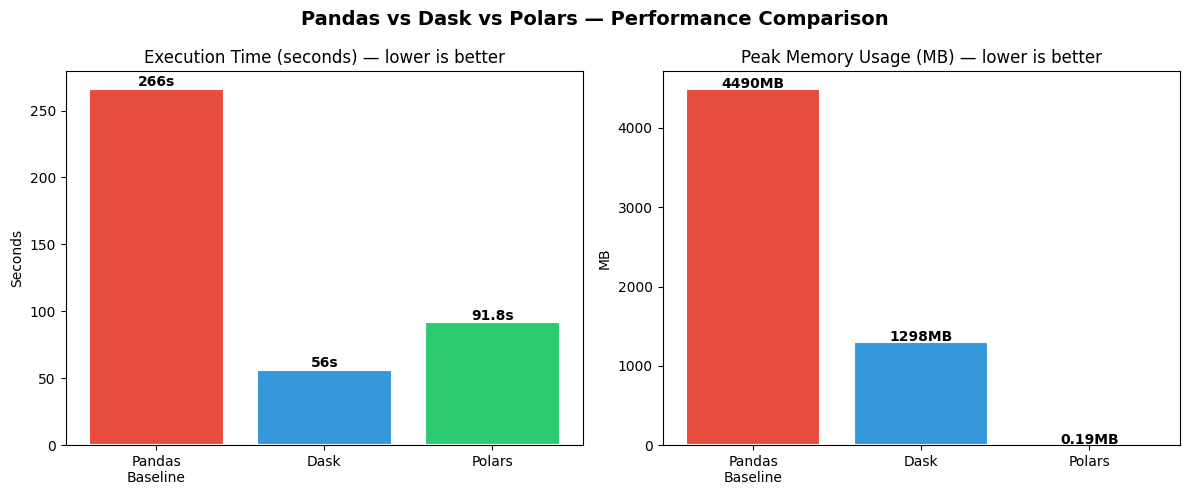

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── DATA ──────────────────────────────────────────────────
libraries   = ['Pandas\nBaseline', 'Dask', 'Polars']
times       = [baseline_time, dask_time, polars_time]   # seconds
memories    = [baseline_memory, dask_memory, polars_memory]  # MB

x = np.arange(len(libraries))
colors = ['#e74c3c', '#3498db', '#2ecc71']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Pandas vs Dask vs Polars — Performance Comparison', fontsize=14, fontweight='bold')

# -- Execution Time --
axes[0].bar(x, times, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Execution Time (seconds) — lower is better')
axes[0].set_xticks(x); axes[0].set_xticklabels(libraries)
axes[0].set_ylabel('Seconds')
for i, v in enumerate(times):
    axes[0].text(i, v + 2, f'{v}s', ha='center', fontweight='bold')

# -- Peak Memory --
axes[1].bar(x, memories, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('Peak Memory Usage (MB) — lower is better')
axes[1].set_xticks(x); axes[1].set_xticklabels(libraries)
axes[1].set_ylabel('MB')
for i, v in enumerate(memories):
    axes[1].text(i, v + 10, f'{v}MB', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('comparison_chart.png', dpi=150)
plt.show()

In [ ]:
comparison = pd.DataFrame({
    'Library':       ['Pandas', 'Dask', 'Polars'],
    'Time (s)':      [baseline_time, dask_time, polars_time],
    'Peak Mem (MB)': [baseline_memory, dask_memory, polars_memory],
    'Speedup vs Pandas': [
        '1.0×',
        f'{round(baseline_time/dask_time, 1)}×',
        f'{round(baseline_time/polars_time, 1)}×'
    ],
    'Memory Reduction': [
        '0%',
        f'{round((baseline_memory - dask_memory)/baseline_memory*100, 1)}%',
        f'{round((baseline_memory - polars_memory)/baseline_memory*100, 1)}%'
    ]
})
print(comparison.to_string(index=False))

Library  Time (s)  Peak Mem (MB) Speedup vs Pandas Memory Reduction
 Pandas     266.0        4490.00              1.0×               0%
   Dask      56.0        1298.00              4.8×            71.1%
 Polars      91.8           0.19              2.9×           100.0%
